<img src="https://raw.githubusercontent.com/astro-transients/tilepy/master/image/tilepy_logo.png" style="height:80px;"/>

# tilepy — Discover the tool in 10 minutes

**tilepy** is an open-source tool that automatically computes observation strategies ("tiling") to cover the region of the sky where a poorly localized transient event might be found — gravitational wave, gamma-ray burst.

This notebook shows you what the tool produces in practice, **without installing anything on your machine**, before you decide whether to use it.

By the end, you will know:
- what tilepy takes as input and what it produces as output,
- how to read an observation tiling map,
- what you need to prepare to use it under real conditions.

---

## 1. Installation (in Colab)

tilepy is available on PyPI, which simplifies installation in a Colab environment (no need for conda here).

> ⏱️ This cell takes about 1 to 2 minutes — tilepy depends on `astropy`, `healpy`, `ligo.skymap`, and `MOCpy`, among others.

**Real-world caveat**: tilepy pins specific versions for some dependencies (`healpy==1.16.2`, `matplotlib<3.9.0`, `scipy<1.14.0`). Since Colab often has more recent versions preinstalled, the installation may require a runtime restart after `pip install`. If a message prompts you to do so (or if `check-version` fails right after installation), go to the menu **Runtime > Restart session**, then rerun the cells from the beginning.

In [1]:
#!pip install tilepy==0.1.dev1197+g328927a45

 tilepy generates many intermediate diagnostic plots while computing the schedule (visibility masks, ranking, per-tile zooms...). 
 
 With Jupyter's default inline backend, matplotlib auto-displays every figure it creates, which floods the notebook. 
 
 Switching to the non-interactive "Agg" backend stops that: we only show the final result explicitly, as a saved image, in section 3.3 below.

In [2]:
import tilepy
import ssl
import certifi
import matplotlib


matplotlib.use("Agg")

print("tilepy is installed, version:", tilepy.__version__)

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

tilepy is installed, version: 0.1.dev1197+g328927a45


Actual prerequisite of the tool: **Python ≥ 3.9** (already the default on Colab).

---

## 2. The problem tilepy solves

When a detector like LIGO/Virgo reports a gravitational wave, the source's position in the sky is not a precise point: it is a **probability map** that can cover hundreds of square degrees. A classic telescope, with a narrow field of view, cannot point "at random" within this region.

tilepy solves this problem by dividing the probable region into **tiles**, ordered by probability, taking into account:
- the position and visibility constraints of the observatory,
- the field of view of the instrument,
- the observing conditions (night, moon, zenith),
- optionally, a galaxy catalog to refine the priority (3D mode).

---

## 3. Demo — a real case

The examples provided with tilepy automatically download a real event map, so there's nothing to prepare in advance. Here we use the map for event `S240904bv` (`cWB` search, LIGO/Virgo/KAGRA O4), fetched directly from GraceDB.

### 3.1 Observatory configuration

Every parameter has a direct, visible effect on the result — you will see its effect concretely in the tiles generated below:

| Parameter | Role |
|---|---|
| `lat`, `lon`, `height` | Observatory position |
| `sunDown`, `moonDown` | Definition of dark-night conditions |
| `FOV` | Instrument field of view (size of a tile) |
| `maxRuns` | Maximum number of scheduled tiles |
| `duration` | Exposure time per tile |

Below we write an `ExampleConfig.ini` file corresponding to a fictional telescope located at La Palma, in **2D** computation mode (no galaxy catalog needed, see section 4).

To keep this demo tidy, the config file and everything generated afterwards (downloaded map, plots, tables) are written to a **temporary folder** instead of cluttering your working directory — it is removed automatically at the end of the notebook (section 3.4).

tilepy internally downloads a couple of files (the skymap, an ephemeris file used for day/night calculations) using bare relative filenames, so they always land in the process's current directory. We move into the temporary folder so those downloads land there too, instead of next to this notebook.

In [3]:
import os
import tempfile
from pathlib import Path


originalDir = os.getcwd()
workDir = Path(tempfile.mkdtemp(prefix="tilepy_quickstart_"))


os.chdir(workDir)

cfgFile = workDir / "ExampleConfig.ini"

cfgFile.write_text(
    """[observatory]
name = CTAO-N
lat = 28.75
lon = -17.5
height = 2200

[visibility]
sunDown = -18
moonDown = -0.5
moonGrey = 65
moonPhase = 60
minMoonSourceSeparation = 30
maxMoonSourceSeparation = 145

[operations]
maxZenith = 70
FOV = 2.0
maxRuns = 20
maxNights = 1
duration = 15
minDuration = 10
useGreytime = False

[tiling]
minimumProbCutforCatalogue = 0.01
minProbcut = 0.002
distCut = 500
doPlot = True
secondRound = False
zenithWeighting = 0.75
percentageMOC = 0.90
reducedNside = 128
HRnside = 512
mangrove = False
algorithm = 2D
strategy = integrated
doRank = True
countPrevious = False
countSubtractedPointingsOutside = False

[general]
downloadMaxRetry = 3
downloadWaitPeriodRetry = 20
"""
)

print(f"Temporary working directory: {workDir}")

Temporary working directory: /var/folders/v_/ky_3980n7_z1_6hvg6ggk1pnd_bs8d/T/tilepy_quickstart_u_zqyl80


### 3.2 Run a scheduling

> ⏱️ Depending on the map resolution, this step can take from a few seconds to 1-2 minutes (map download + tile computation).

In [4]:
# Import tilepy's main building blocks
from tilepy.include.CampaignDefinition import ObservationParameters
from tilepy.include.ObservationScheduler import GetSchedule
from tilepy.include.PointingTools import getdate

/Users/as287950/projetCEA/tilepy_old/.venv/lib/python3.11/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/Users/as287950/projetCEA/tilepy_old/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# URL to the event's localization FITS file (automatic download)
skymap = (
    "https://gracedb.ligo.org/api/superevents/S240904bv/files/cwb.multiorder.fits,0"
)

# Reference date and time for the start of the scheduling
obsTime = getdate("2024-09-04 14:51:47")

# File listing any tiles already observed (none here)
pointingsFile = None

# Folder for an optional galaxy catalog (not used in 2D mode, never created)
datasetDir = str(workDir / "dataset")

# Output folder (inside the temporary working directory created above)
outDir = str(workDir / "output")

# Galaxy catalog name (none in 2D mode)
galcatName = None

In [6]:
# Parse the input parameters
obspar = ObservationParameters()
obspar.add_parsed_args(skymap, obsTime, datasetDir, galcatName, outDir, pointingsFile)
obspar.from_configfile(cfgFile)

print(obspar)

============== Observation Parameters ======================
Observatory Name: CTAO-N
Event Name: None
obsTime: 2024-09-04 14:51:47
---------------------- Strategy ----------------------
Algorithm = 2D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True
Count Previous = False, Subtract Pointings Outside the current 0.9 MOC region = False
Second Round = False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.75 deg, -17.5 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.0, Duration: 15.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 20, Max Nights: 1
Visibility: -18, -0.5, 65, 60, 0.0
Min Moon Source Separation: 30
Max Moon Source Separation: 145
Geomagnetic Threshold for SAA: 0
Max Zenith: 70.0, Zenith Weighting: 0.75
FoV number of sides: 0, FoV rotation: 0,Priority for FoV proximity and Probability: 0.0, Zenith Weighting: 0.0
--------------------- Skymap considerations ----------------
Skymap: https://gracedb.ligo.

In [7]:
import shutil

# Clean up results from a previous run to avoid picking up
# the wrong folder during visualization (glob.glob) below
shutil.rmtree(outDir, ignore_errors=True)

In [8]:
# Run the scheduler on the loaded example
try:
    GetSchedule(obspar)
except Exception as e:
    print("❌ The download or computation failed.")
    print(f"Error details: {e}")
    print(
        "\nCheck that:\n"
        "- you have run the SSL certificate installation cell (at the top of the notebook)\n"
        "- your internet connection is working\n"
        "- GraceDB (gracedb.ligo.org) is reachable: https://gracedb.ligo.org\n"
    )

The filename is cwb.multiorder.fits,0
Starting the 2D pointing calculation with the following parameters

Filename:  G508457
Date: 2024-09-04 14:51:47
Previous pointings: None
Dataset: /var/folders/v_/ky_3980n7_z1_6hvg6ggk1pnd_bs8d/T/tilepy_quickstart_u_zqyl80/dataset
Output: /var/folders/v_/ky_3980n7_z1_6hvg6ggk1pnd_bs8d/T/tilepy_quickstart_u_zqyl80/output/G508457
90% area = 3459.5684055604306. 50% area = 958.4733428311524

Obspar:
============== Observation Parameters ======================
Observatory Name: CTAO-N
Event Name: G508457
obsTime: 2024-09-04 14:51:47
---------------------- Strategy ----------------------
Algorithm = 2D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True
Count Previous = False, Subtract Pointings Outside the current 0.9 MOC region = False
Second Round = False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.75 deg, -17.5 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.0, Duration: 15.0

### 3.3 Visualize the result

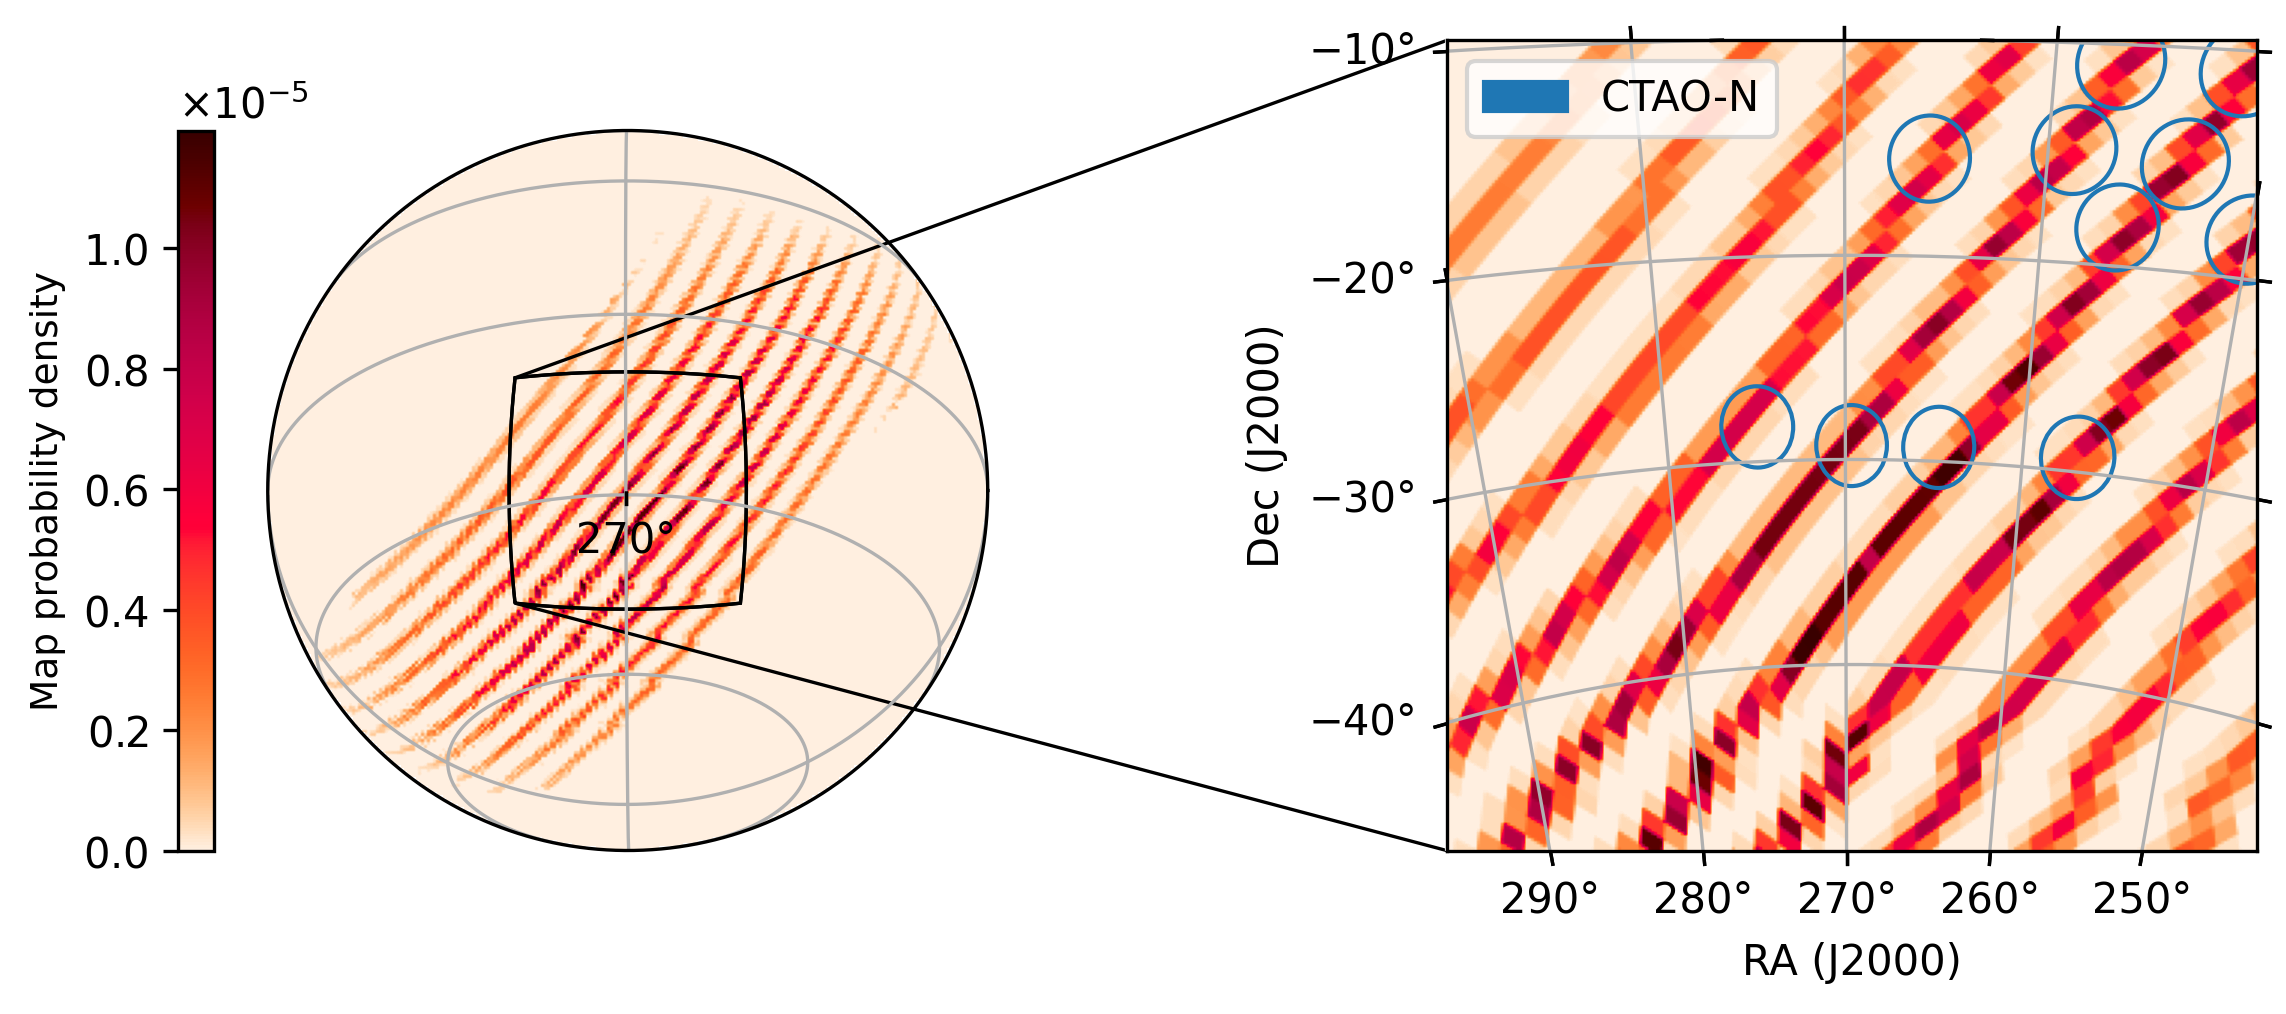

In [9]:
# Display the probability map with tiles overlaid
import glob

from IPython.display import Image, display

resultDir = glob.glob(f"{outDir}/*/PGinFoV")[0]
prettyMap = glob.glob(f"{resultDir}/Plot_PrettyMap_*.png")[0]
display(Image(filename=prettyMap))

In [10]:
# Display the tile table: rank, coordinates, covered probability, observation time
from astropy.io import ascii

pointingsFileOut = glob.glob(f"{resultDir}/SuggestedPointings_2DProbOptimisation.txt")[
    0
]
tiles = ascii.read(pointingsFileOut)
tiles.sort("PGW", reverse=True)
tiles["Rank"] = range(1, len(tiles) + 1)

tiles["Rank", "Time[UTC]", "RA[deg]", "DEC[deg]", "PGW", "Duration"]

Rank,Time[UTC],RA[deg],DEC[deg],PGW,Duration
int64,str19,float64,float64,float64,float64
1,2024-09-05 03:03:02,93.8672,33.5101,0.0038,15.0
2,2024-09-05 03:18:02,101.9531,39.8384,0.0036,15.0
3,2024-09-05 02:18:02,89.6311,44.2015,0.0036,15.0
4,2024-09-05 02:48:02,97.8099,44.598,0.0035,15.0
5,2024-09-04 20:48:02,269.6484,-29.3132,0.0032,15.0
6,2024-09-05 02:33:02,94.3805,47.7497,0.003,15.0
7,2024-09-04 21:18:02,253.4766,-15.0948,0.0029,15.0
8,2024-09-04 21:03:02,264.7266,-29.3132,0.0029,15.0
9,2024-09-05 01:48:02,82.8151,45.3892,0.0027,15.0




---

## 4. Going further: 3D mode

2D mode is enough for most cases and for this demo. tilepy also offers a **3D mode**, which weights tiles by the presence of known galaxies (GLADE+ catalog), useful when the event's distance is well constrained.

⚠️ This mode requires downloading and converting the GLADE+ catalog (several 
GB), which is beyond the scope of a quick demo. This section is included 
only to show that the tool goes beyond the simple case presented here — 
refer to the documentation if you want to use it.

### 3.4 Clean up temporary files

The config file, the downloaded skymap, and the output plots/tables all lived in the temporary folder created in section 3.1. The map and table are already displayed above, so we can safely delete it — nothing of value is lost, and nothing lingers in your working directory.

In [11]:
import shutil

os.chdir(originalDir)
shutil.rmtree(workDir, ignore_errors=True)
print(f"Temporary folder removed: {workDir}")

Temporary folder removed: /var/folders/v_/ky_3980n7_z1_6hvg6ggk1pnd_bs8d/T/tilepy_quickstart_u_zqyl80


In [12]:
# (Not run in this demo — requires the GLADE+ catalog)
# obspar.algorithm = "3D"  # and galcatName pointing to the converted GLADE+ catalog

---

## 5. Key takeaways

1. **Input**: an event localization map + an observatory configuration.
2. **Output**: a list of tiles ranked by probability, with observation times, directly usable by a telescope.
3. **Entry cost**: light in 2D, heavier in 3D (galaxy catalog).

---

## 6. Going further

- Documentation: https://tilepy.readthedocs.io
- Repository and full examples (`examples/launcher` folder): https://github.com/astro-transients/tilepy
- Community forum: https://forum.astro-colibri.science/c/instrumentation-and-tools/tilepy
- Contact: astro.tilepy@gmail.com

**Suggested next step**: clone the repository and explore `examples/launcher`, which contains the full Jupyter notebooks used to reproduce the use cases from tilepy's reference paper.